## 8.1 양자 경제물리학 (Quantum Econophysics)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from scipy.stats import powerlaw
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

%matplotlib inline

In [2]:
# 파라미터
a = 1.5  # 멱법칙 지수
num_agents = 1024  # 에이전트 수 (2의 거듭제곱이어야 함)
initial_wealth = 100  # 각 에이전트의 초기 부
num_transactions = 100000  # 거래 횟수

In [3]:
# 부 분포 초기화
wealth = np.full(num_agents, initial_wealth)

In [4]:
# 거래 수행 (무작위로 두 에이전트가 부를 주고받음 — 부 보존)
for _ in range(num_transactions):
    i, j = np.random.choice(num_agents, 2, replace=False)
    transaction_amount = min(wealth[i], wealth[j]) * np.random.random()
    if np.random.random() < 0.5:
        wealth[i] += transaction_amount
        wealth[j] -= transaction_amount
    else:
        wealth[i] -= transaction_amount
        wealth[j] += transaction_amount

(array([6.26653688e-03, 8.47710503e-05, 5.21668002e-05, 4.56459502e-05,
        1.30417001e-05, 6.52085003e-06, 1.30417001e-05, 1.30417001e-05,
        6.52085003e-06, 3.26042501e-05, 1.95625501e-05, 1.30417001e-05,
        1.95625501e-05, 1.30417001e-05, 6.52085003e-06, 1.30417001e-05,
        0.00000000e+00, 6.52085003e-06, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 6.52085003e-06, 0.00000000e+00, 0.00000000e+00,
        2.60834001e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 6.52085003e-06, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 6.52085003e-06, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 6.52085003e-06]),
 array([   0.  ,  149.76,  299.52,  449.28,  599.04,  748.8 ,  898.56,
        1048.32, 1198.0

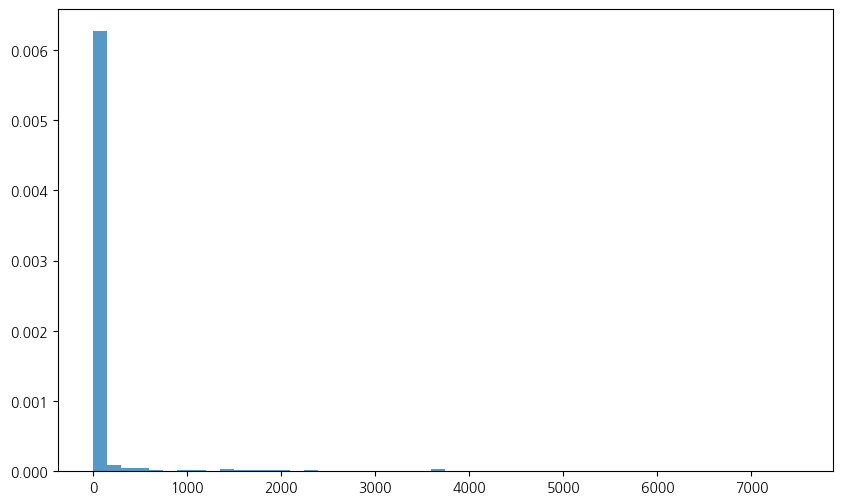

In [5]:
# 부 분포 그리기
plt.figure(figsize=(10, 6))
plt.hist(wealth, bins=50, density=True, alpha=0.75, label='부 분포')

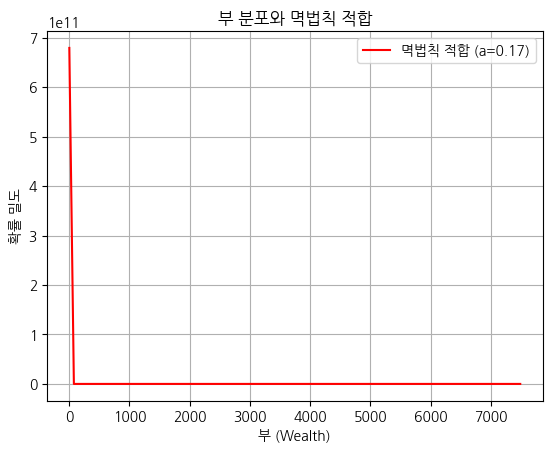

In [6]:
# 멱법칙 분포 적합 및 그리기
xmin = 1  # 고려할 최소 부 값
fitted_params = powerlaw.fit(wealth[wealth >= xmin])
x = np.linspace(xmin, wealth.max(), 100)
pdf = powerlaw.pdf(x, *fitted_params)

plt.plot(x, pdf, 'r-', label=f'멱법칙 적합 (a={fitted_params[0]:.2f})')
plt.xlabel('부 (Wealth)')
plt.ylabel('확률 밀도')
plt.title('부 분포와 멱법칙 적합')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# 부 분포를 표현하는 양자회로
num_qubits = int(np.log2(num_agents))
qc = QuantumCircuit(num_qubits)

In [8]:
# 부 분포를 양자 상태로 매핑 (정규화 후 제곱근을 진폭으로)
normalized_wealth = wealth / wealth.sum()
state_vector = np.sqrt(normalized_wealth)

In [9]:
# 양자 상태 초기화
qc.initialize(state_vector, range(num_qubits))
qc.save_statevector()

In [10]:
# AerSimulator로 시뮬레이션
simulator = AerSimulator(method='statevector')

In [11]:
# 시뮬레이터용으로 회로 트랜스파일
qc = transpile(qc, simulator)

In [12]:
# 회로 실행 후 상태벡터 획득
result = simulator.run(qc).result()
statevector = result.get_statevector(qc)

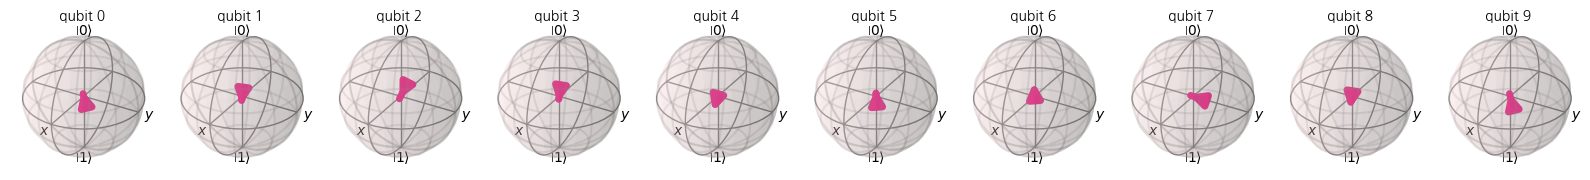

In [13]:
# 블로흐 구 시각화
plot_bloch_multivector(statevector)
plt.show()

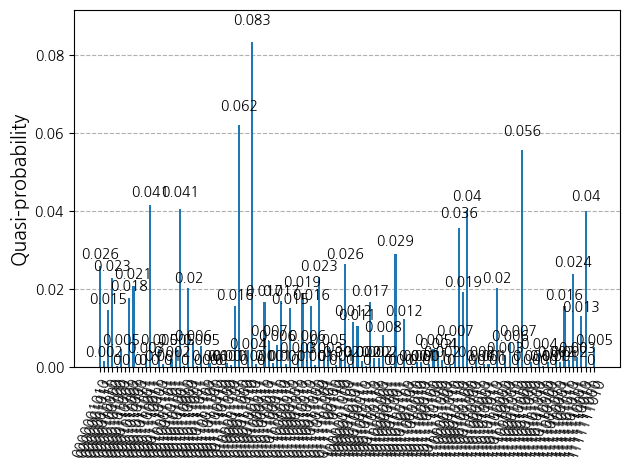

In [14]:
# 측정 확률 히스토그램
counts = Statevector(statevector).probabilities_dict()
plot_histogram(counts)
plt.show()